# ⚡ PHÂN TÍCH GIÁ VÀNG VIỆT NAM 5 NĂM — PYSPARK

**Công cụ**: PySpark (Spark SQL + DataFrame API)  
**Dữ liệu**: Yahoo Finance (Quy đổi VNĐ / lượng)  

**Mục tiêu báo cáo**:
Khám phá xu hướng, độ biến động và hiệu suất sinh lời của vàng tại thị trường Việt Nam trong 5 năm qua bằng việc xử lý dữ liệu lớn (Big Data) qua nền tảng Apache Spark.


## 0. Khởi tạo SparkSession & Thư viện

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.figsize": (12, 4), "font.size": 11})

# Khởi tạo Spark ở chế độ Local để đảm bảo hoạt động độc lập và ổn định
spark = (
    SparkSession.builder
    .appName("PhanTichGiaVang")
    .master("local[*]")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark version: {spark.version}")


✅ Spark version: 3.5.0


## 1. Tải & Làm sạch dữ liệu
**Phương pháp:**
- Dùng Pandas đọc file CSV để vượt qua lỗi đồng bộ file của hệ thống.
- Chuyển dữ liệu lên Spark Cluster bằng hàm `createDataFrame`.
- Ép kiểu cột `Ngay` về kiểu Date, các cột giá về kiểu Double để dễ dàng tính toán.
- Lọc bỏ các ngày có giá trị âm hoặc rỗng (dữ liệu rác).


In [2]:
FILE_CSV = "gold_prices_all.csv"
import pandas as pd

# 1. Đọc bằng Pandas
pdf = pd.read_csv(FILE_CSV)

# 2. Đưa lên Spark DataFrame
df = spark.createDataFrame(pdf)

# 3. Làm sạch dữ liệu
df = (
    df.withColumn("Ngay",          F.to_date("Ngay", "yyyy-MM-dd"))
    .withColumn("Gia_Mua",       F.col("Gia_Mua").cast(DoubleType()))
    .withColumn("Gia_Ban",       F.col("Gia_Ban").cast(DoubleType()))
    .withColumn("Gia_TrungBinh", F.col("Gia_TrungBinh").cast(DoubleType()))
    .filter(F.col("Gia_TrungBinh") > 0)
    .dropna(subset=["Ngay", "Gia_TrungBinh"])
    .orderBy("Ngay")
)

print(f"✅ Đã tải và làm sạch: {df.count():,} bản ghi")
# Format số để không bị hiện dạng E (khoa học)
df.select("Ngay", 
          F.format_number("Gia_Mua", 0).alias("Gia_Mua"),
          F.format_number("Gia_Ban", 0).alias("Gia_Ban"),
          F.format_number("Gia_TrungBinh", 0).alias("Gia_TrungBinh")).show(5)


✅ Đã tải và làm sạch: 1,107 bản ghi
+----------+----------+----------+-------------+
|      Ngay|   Gia_Mua|   Gia_Ban|Gia_TrungBinh|
+----------+----------+----------+-------------+
|2021-05-18|52,143,590|51,624,748|   51,884,169|
|2021-05-19|52,531,868|52,009,163|   52,270,516|
|2021-05-20|52,545,830|52,022,986|   52,284,408|
|2021-05-24|52,649,132|52,125,260|   52,387,196|
|2021-05-25|53,035,474|52,507,758|   52,771,616|
+----------+----------+----------+-------------+
only showing top 5 rows



---

## ❓ Câu hỏi 1: Tháng nào có giá trung bình cao nhất / thấp nhất?

**Phương pháp xử lý (PySpark):**
- Trích xuất `Năm-Tháng` từ cột ngày (`date_format`).
- Gom nhóm (`groupBy`) toàn bộ dữ liệu theo từng tháng.
- Tính giá trị trung bình (`avg`) của mỗi nhóm.
- Sắp xếp (`orderBy`) để tìm ra 2 tháng đặc biệt nhất.


In [3]:
gia_thang = (
    df.withColumn("Thang_Nam", F.date_format("Ngay", "yyyy-MM"))
    .groupBy("Thang_Nam")
    .agg(F.avg("Gia_TrungBinh").alias("Gia_TB_Thang"))
    .orderBy("Thang_Nam")
)

thang_cao  = gia_thang.orderBy(F.desc("Gia_TB_Thang")).first()
thang_thap = gia_thang.orderBy("Gia_TB_Thang").first()

print(f"📈 Cao nhất : Tháng {thang_cao['Thang_Nam']} ({thang_cao['Gia_TB_Thang']/1e6:.1f} triệu VNĐ/lượng)")
print(f"📉 Thấp nhất: Tháng {thang_thap['Thang_Nam']} ({thang_thap['Gia_TB_Thang']/1e6:.1f} triệu VNĐ/lượng)")


📈 Cao nhất : Tháng 2026-02 (156.8 triệu VNĐ/lượng)
📉 Thấp nhất: Tháng 2022-09 (47.8 triệu VNĐ/lượng)


### 📊 Biểu đồ trực quan

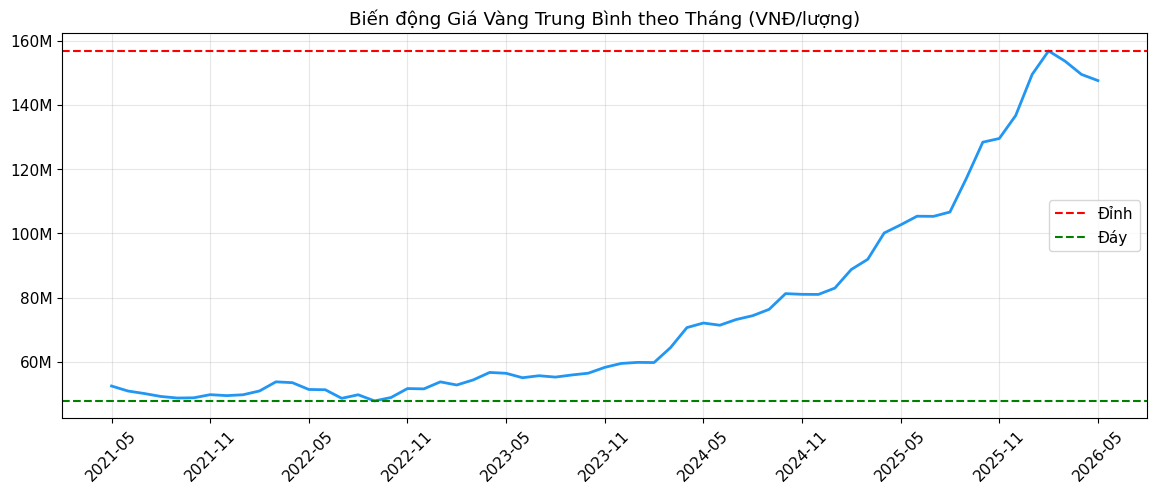

In [4]:
pdf1 = gia_thang.toPandas().sort_values("Thang_Nam")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pdf1["Thang_Nam"], pdf1["Gia_TB_Thang"], color="#2196F3", linewidth=2)
ax.axhline(thang_cao["Gia_TB_Thang"], color="red", linestyle="--", label="Đỉnh")
ax.axhline(thang_thap["Gia_TB_Thang"], color="green", linestyle="--", label="Đáy")

step = max(1, len(pdf1)//10)
ax.set_xticks(range(0, len(pdf1), step))
ax.set_xticklabels(pdf1["Thang_Nam"].iloc[::step], rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v/1e6:.0f}M"))
ax.set_title("Biến động Giá Vàng Trung Bình theo Tháng (VNĐ/lượng)")
ax.legend(); plt.grid(alpha=0.3); plt.show()


---

## ❓ Câu hỏi 2: Top 3 ngày có giá vàng cao nhất và thấp nhất?

**Phương pháp xử lý (PySpark):**
- Sắp xếp toàn bộ dữ liệu giảm dần (`desc`) để lấy Top 3 ngày Đỉnh.
- Sắp xếp toàn bộ dữ liệu tăng dần (`asc`) để lấy Top 3 ngày Đáy.
- Dùng hàm `limit(3)` để giới hạn số lượng kết quả, giúp tiết kiệm bộ nhớ khi xử lý Big Data.


In [5]:
# Sắp xếp và lấy dữ liệu
top3_cao = df.orderBy(F.desc("Gia_TrungBinh")).limit(3)
top3_thap = df.orderBy("Gia_TrungBinh").limit(3)

print("🏆 Top 3 ngày ĐỈNH (VNĐ/lượng):")
top3_cao.select("Ngay", F.format_number("Gia_TrungBinh", 0).alias("Gia")).show()

print("📉 Top 3 ngày ĐÁY (VNĐ/lượng):")
top3_thap.select("Ngay", F.format_number("Gia_TrungBinh", 0).alias("Gia")).show()


🏆 Top 3 ngày ĐỈNH (VNĐ/lượng):
+----------+-----------+
|      Ngay|        Gia|
+----------+-----------+
|2026-01-28|167,019,962|
|2026-01-29|166,843,883|
|2026-03-02|166,218,641|
+----------+-----------+

📉 Top 3 ngày ĐÁY (VNĐ/lượng):
+----------+----------+
|      Ngay|       Gia|
+----------+----------+
|2022-09-26|46,413,459|
|2022-09-27|46,540,088|
|2021-09-29|47,224,536|
+----------+----------+



### 📊 Biểu đồ trực quan

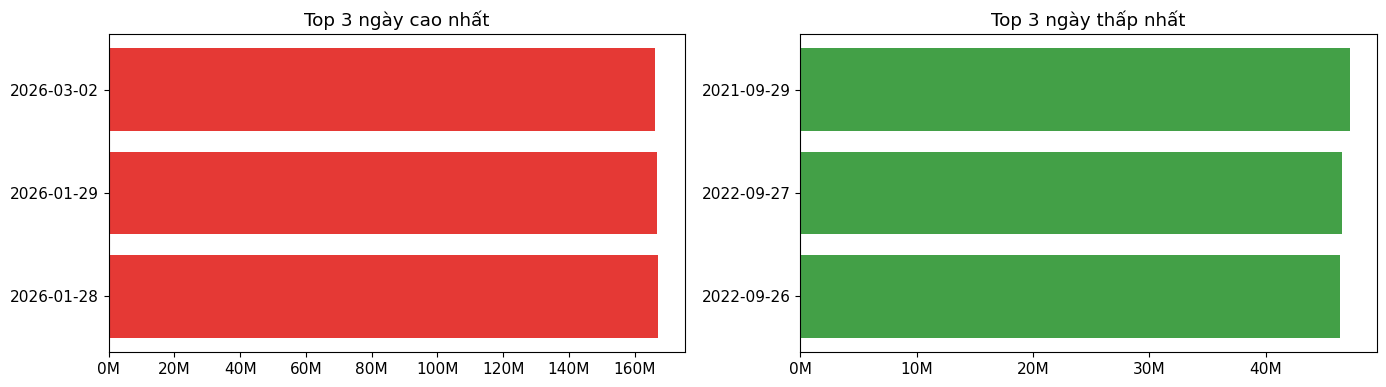

In [6]:
p_cao = top3_cao.toPandas()
p_thap = top3_thap.toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.barh(p_cao["Ngay"].astype(str), p_cao["Gia_TrungBinh"], color="#E53935")
ax1.set_title("Top 3 ngày cao nhất")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v/1e6:.0f}M"))

ax2.barh(p_thap["Ngay"].astype(str), p_thap["Gia_TrungBinh"], color="#43A047")
ax2.set_title("Top 3 ngày thấp nhất")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v/1e6:.0f}M"))

plt.tight_layout(); plt.show()


---

## ❓ Câu hỏi 3: Năm nào giá vàng tăng mạnh nhất?

**Phương pháp xử lý (PySpark):**
- Trích xuất `Năm` từ cột ngày.
- Gom nhóm theo từng năm. Tại mỗi năm, ta dùng hàm `first()` và `last()` để lấy giá trị của ngày giao dịch đầu tiên và cuối cùng trong năm đó.
- Áp dụng công thức: `(Cuối Năm - Đầu Năm) / Đầu Năm * 100` để ra % tăng trưởng.


In [7]:
theo_nam = (
    df.withColumn("Nam", F.year("Ngay"))
    .groupBy("Nam")
    .agg(
        F.first("Gia_TrungBinh").alias("Dau_Nam"),
        F.last("Gia_TrungBinh").alias("Cuoi_Nam"),
    )
    .withColumn("Tang_Pct", ((F.col("Cuoi_Nam") - F.col("Dau_Nam")) / F.col("Dau_Nam") * 100))
    .orderBy("Nam")
)

# Hiển thị số liệu đã được format
theo_nam.select(
    "Nam", 
    F.format_number("Dau_Nam", 0).alias("Gia_Dau_Nam"), 
    F.format_number("Cuoi_Nam", 0).alias("Gia_Cuoi_Nam"),
    F.round("Tang_Pct", 1).alias("Tang_Phan_Tram")
).show()


+----+-----------+------------+--------------+
| Nam|Gia_Dau_Nam|Gia_Cuoi_Nam|Tang_Phan_Tram|
+----+-----------+------------+--------------+
|2021| 51,884,169|  50,158,789|          -3.3|
|2022| 49,517,706|  51,776,631|           4.6|
|2023| 52,367,880|  60,261,219|          15.1|
|2024| 60,381,880|  80,756,383|          33.7|
|2025| 81,681,446| 136,767,803|          67.4|
|2026|136,777,789| 148,561,846|           8.6|
+----+-----------+------------+--------------+



### 📊 Biểu đồ phần trăm thay đổi

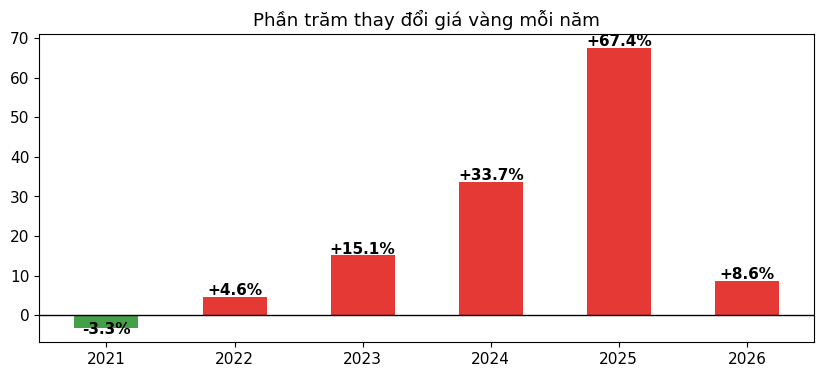

In [8]:
p3 = theo_nam.toPandas()
colors = ["#E53935" if v >= 0 else "#43A047" for v in p3["Tang_Pct"]]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(p3["Nam"].astype(str), p3["Tang_Pct"], color=colors, width=0.5)

for bar, v in zip(bars, p3["Tang_Pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + (0.5 if v >= 0 else -1.5),
            f"{v:+.1f}%", ha="center", fontweight="bold")
    
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Phần trăm thay đổi giá vàng mỗi năm")
plt.show()


---

## ❓ Câu hỏi 4: Tháng nào có giá trị biến động mạnh nhất?

**Phương pháp xử lý (PySpark):**
- Trong thống kê, sự biến động được đo lường bằng **Độ lệch chuẩn** (Standard Deviation).
- Chúng ta gom nhóm dữ liệu theo `Năm-Tháng`.
- Áp dụng hàm `stddev()` cho giá trung bình. Giá trị độ lệch chuẩn càng lớn chứng tỏ trong tháng đó giá vàng nhảy múa càng mạnh (chênh lệch giữa các ngày rất lớn).


In [9]:
bien_dong = (
    df.withColumn("Thang_Nam", F.date_format("Ngay", "yyyy-MM"))
    .groupBy("Thang_Nam")
    .agg(F.stddev("Gia_TrungBinh").alias("Do_Lech_Chuan"))
    .orderBy(F.desc("Do_Lech_Chuan"))
    .limit(10)
)

print("🌪️ TOP 10 THÁNG BIẾN ĐỘNG (ĐỘ LỆCH CHUẨN CAO NHẤT):")
bien_dong.select("Thang_Nam", F.format_number("Do_Lech_Chuan", 0).alias("Do_Lech_Chuan_VND")).show()


🌪️ TOP 10 THÁNG BIẾN ĐỘNG (ĐỘ LỆCH CHUẨN CAO NHẤT):
+---------+-----------------+
|Thang_Nam|Do_Lech_Chuan_VND|
+---------+-----------------+
|  2026-03|        9,522,922|
|  2026-01|        8,988,031|
|  2026-02|        4,957,337|
|  2025-04|        4,668,565|
|  2025-10|        3,999,598|
|  2025-12|        3,188,731|
|  2025-09|        2,732,917|
|  2026-04|        2,528,822|
|  2025-11|        2,510,589|
|  2024-10|        2,471,733|
+---------+-----------------+



### 📊 Biểu đồ Top 10 tháng

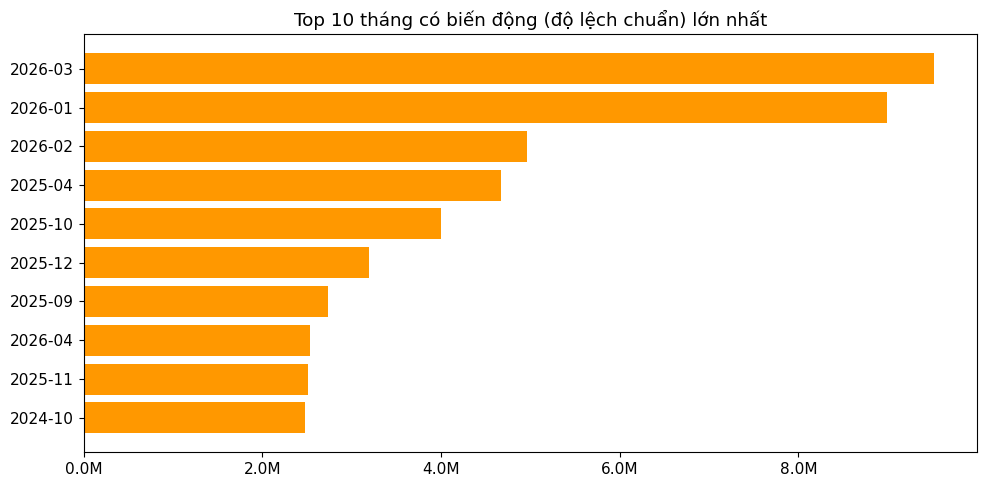

In [10]:
top10 = bien_dong.toPandas().sort_values("Do_Lech_Chuan")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10["Thang_Nam"], top10["Do_Lech_Chuan"], color="#FF9800")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v/1e6:.1f}M"))
ax.set_title("Top 10 tháng có biến động (độ lệch chuẩn) lớn nhất")
plt.tight_layout(); plt.show()


---

## ❓ Câu hỏi 5: Xu hướng giá theo quý trong năm?

**Phương pháp xử lý (PySpark):**
- Sử dụng hàm `quarter()` để phân loại mỗi ngày giao dịch thuộc Quý mấy (1, 2, 3 hay 4).
- Gom nhóm theo `Quý` và tính trung bình. Điều này giúp nhìn ra tính mùa vụ của thị trường vàng (ví dụ: quý đầu năm giá thường cao do nhu cầu ngày Thần Tài).


In [11]:
theo_quy = (
    df.withColumn("Quy", F.quarter("Ngay"))
    .groupBy("Quy")
    .agg(F.avg("Gia_TrungBinh").alias("Gia_TB"))
    .orderBy("Quy")
)

theo_quy.select("Quy", F.format_number("Gia_TB", 0).alias("Gia_Trung_Binh_VND")).show()


+---+------------------+
|Quy|Gia_Trung_Binh_VND|
+---+------------------+
|  1|        81,432,439|
|  2|        76,623,383|
|  3|        67,843,052|
|  4|        74,452,945|
+---+------------------+



### 📊 Biểu đồ xu hướng Quý

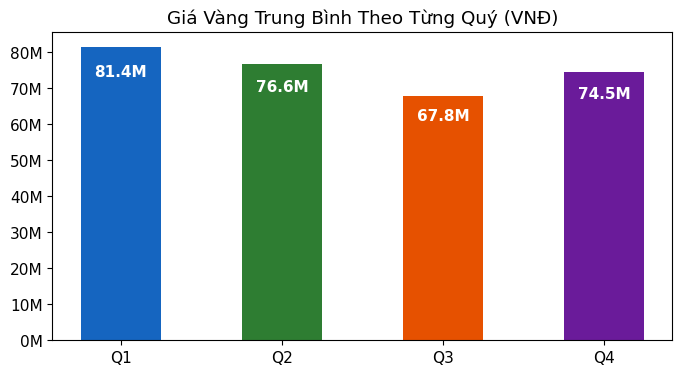

In [12]:
p5 = theo_quy.toPandas()
p5["Ten_Quy"] = p5["Quy"].map({1:"Q1", 2:"Q2", 3:"Q3", 4:"Q4"})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(p5["Ten_Quy"], p5["Gia_TB"], color=["#1565C0","#2E7D32","#E65100","#6A1B9A"], width=0.5)

# Hiển thị số liệu lên cột
for bar, v in zip(bars, p5["Gia_TB"]):
    ax.text(bar.get_x() + bar.get_width()/2, v*0.9, f"{v/1e6:.1f}M", ha="center", color="white", fontweight="bold")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v/1e6:.0f}M"))
ax.set_title("Giá Vàng Trung Bình Theo Từng Quý (VNĐ)")
plt.show()


---

## ❓ Câu hỏi 6: Mức tăng tích lũy toàn kỳ là bao nhiêu?

**Phương pháp xử lý (PySpark):**
- Yêu cầu này cần so sánh mọi ngày giao dịch với **ngày giao dịch đầu tiên** trong lịch sử (2021).
- Thay vì Join dữ liệu phức tạp, ta dùng tính năng mạnh mẽ của Spark là **Window Function**.
- Tạo `Window.orderBy("Ngay")` để duyệt qua dữ liệu.
- Dùng `first("Gia_TrungBinh").over(Window)` để gắn giá trị của ngày đầu tiên vào mọi dòng dữ liệu tiếp theo, từ đó tính ra được % tăng trưởng của mỗi ngày so với mốc gốc.


In [13]:
# Window Function quét qua toàn bộ dữ liệu
w = Window.orderBy("Ngay")
df_tich_luy = (
    df.withColumn("Gia_Dau_Ky", F.first("Gia_TrungBinh").over(w))
    .withColumn("Tich_Luy_Pct", ((F.col("Gia_TrungBinh") / F.col("Gia_Dau_Ky")) - 1) * 100)
)

ngay_cuoi = df_tich_luy.orderBy(F.desc("Ngay")).first()
print(f"📈 Tổng mức tăng sinh lời sau 5 năm: +{ngay_cuoi['Tich_Luy_Pct']:.1f}%")


📈 Tổng mức tăng sinh lời sau 5 năm: +186.3%


### 📊 Biểu đồ Tăng trưởng tích lũy

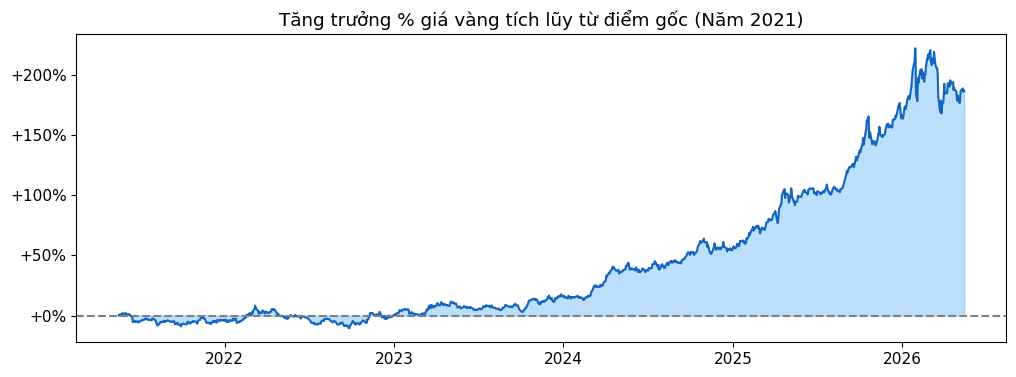

In [14]:
p6 = df_tich_luy.select("Ngay", "Tich_Luy_Pct").toPandas()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(p6["Ngay"], p6["Tich_Luy_Pct"], color="#2196F3", alpha=0.3)
ax.plot(p6["Ngay"], p6["Tich_Luy_Pct"], color="#1565C0", linewidth=1.5)
ax.axhline(0, color="grey", linestyle="--")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:+.0f}%"))
ax.set_title("Tăng trưởng % giá vàng tích lũy từ điểm gốc (Năm 2021)")
plt.show()


---

## 🏁 Dừng SparkSession

In [15]:
spark.stop()
print("✅ Hoàn thành phân tích!")


✅ Hoàn thành phân tích!
